### Visualize the GSEA results in R for each cell type

In [1]:
library(tidyverse)
library(cowplot)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘cowplot’


The following object is masked from ‘package:lubridate’:

    stamp




In [2]:
#contrasts <- c("sex", "aging", "development",  "disease")
contrasts <- c("sex", "aging")

#contrast_names <- c("sex_male_vs_female", "age-group_old_vs_young", "age-group_fetal_vs_young", "disease-binary_Y_vs_N")
contrast_names <- c("sex_male_vs_female", "age_group_old_vs_young")

cell_types <- c("Adipocyte", "Cardiomyocyte", "Endocardial", "Endothelial", "Epicardial",
              "Fibroblast", "Lymphoid", "LEC", "Mast", "Myeloid", "Neuronal", "Pericyte", "vSMC")

q_val_threshold <- 0.05
top_n <- 5

gsea_results_dir <- "gseapy_results_dir/"

# value to add so that the q value is not 0
eps <- 1e-10

In [3]:
extract_top_n_gene_sets <- function(gsea_results_dir, cell_type, contrast, contrast_name,
                                    q_value_threshold, top_n, eps = 1e-10) {

  # read the GSEA results file
  results_file_path <- paste0(gsea_results_dir, cell_type, "_", contrast_name, "_gseapy_results.csv")

  if (!file.exists(results_file_path)) {
    message("File not found: ", results_file_path)
    return(NULL)
  }
    
  gsea_results_df <- read_csv(results_file_path, 
                              show_col_types = FALSE, col_names = TRUE) 
  
  # filter significant results based on the q-value threshold
  significant_res_df <- gsea_results_df %>%
    filter(`FDR q-val` < q_value_threshold)
  
  # get top N upregulated gene sets
  sig_up_df <- significant_res_df %>%
    filter(NES > 0) %>%
    arrange(`FDR q-val`) %>%
    head(top_n)
  sig_up_df$direction <- "up"
  
  # get top N downregulated gene sets
  sig_down_df <- significant_res_df %>%
    filter(NES < 0) %>%
    arrange(`FDR q-val`) %>%
    head(top_n)
  sig_down_df$direction <- "down"
  
  # combine up and down gene sets
  combined_df <- bind_rows(sig_up_df, sig_down_df) %>%
    mutate(
      neg_log10_q = -log10(`FDR q-val` + eps),
      contrast = contrast,
      cell_type = cell_type
    )
  
  return(combined_df)
}

In [4]:
# initialize an empty list to store the data frames
all_dfs_list <- list()

# loop through each cell_type and contrast
for (cell_type in cell_types) {
  for (i in seq_along(contrast_names))  {

    contrast <- contrasts[i]  
    contrast_name <- contrast_names[i]
    
    # call the function to extract the top N gene sets
    combined_df <- extract_top_n_gene_sets(
      gsea_results_dir = gsea_results_dir, 
      cell_type = cell_type,
      contrast_name = contrast_name,
      contrast = contrast,
      q_value_threshold = q_val_threshold, 
      top_n = top_n
    )

    # if not null, then append the result to the list
    if (! is.null(combined_df) ) {
        all_dfs_list <- append(all_dfs_list, list(combined_df))
    }
      
  }
}

# combine all data frames in the list into one
all_gsea_df <- bind_rows(all_dfs_list)

New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`


In [5]:
# Replace underscore with space
all_gsea_df$Term <- gsub("_", " ", all_gsea_df$Term)

# Perform text wrapping for GO terms at natural spaces to fit within a width of 20 characters
library(stringr)
all_gsea_df$Term <- str_wrap(all_gsea_df$Term, width = 25)

In [6]:
# order the contrasts
all_gsea_df$contrast  <- factor(all_gsea_df$contrast, c("sex", "aging", "development", "disease"))

In [7]:
output_dir <- "GSEA_facet_plots/"
dir.create(output_dir)

In [19]:
produce_cell_type_plot <- function(all_results_df, cell_type_val) {
  
  cell_type_df <- all_results_df %>%
    filter(cell_type == cell_type_val)
  
  p <- ggplot(cell_type_df, aes(x = NES, y = Term, size = neg_log10_q, color = NES)) +
    geom_point() +
    scale_color_gradient2(
        low = "blue",  
        mid = "white", 
        high = "red",  
        midpoint = 0   
    ) +
    facet_wrap(~ contrast, ncol = 2, scales = "free_y") +  
    scale_size_continuous(range = c(1, 10)) +  
    theme_minimal() +
    theme(axis.text.y = element_text(size = 8),  
          strip.text = element_text(size = 10),
          legend.title = element_text(size = 10),
          legend.text = element_text(size = 8), hjust = 0.5,
          plot.title = element_text(size = 14, hjust = 0.5), 
          legend.position = "bottom") +
    labs(x = "NES", y = "Term", size = "-log10(q)", title = paste("Cell Type:", cell_type))
  
  return(p)
}

Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”


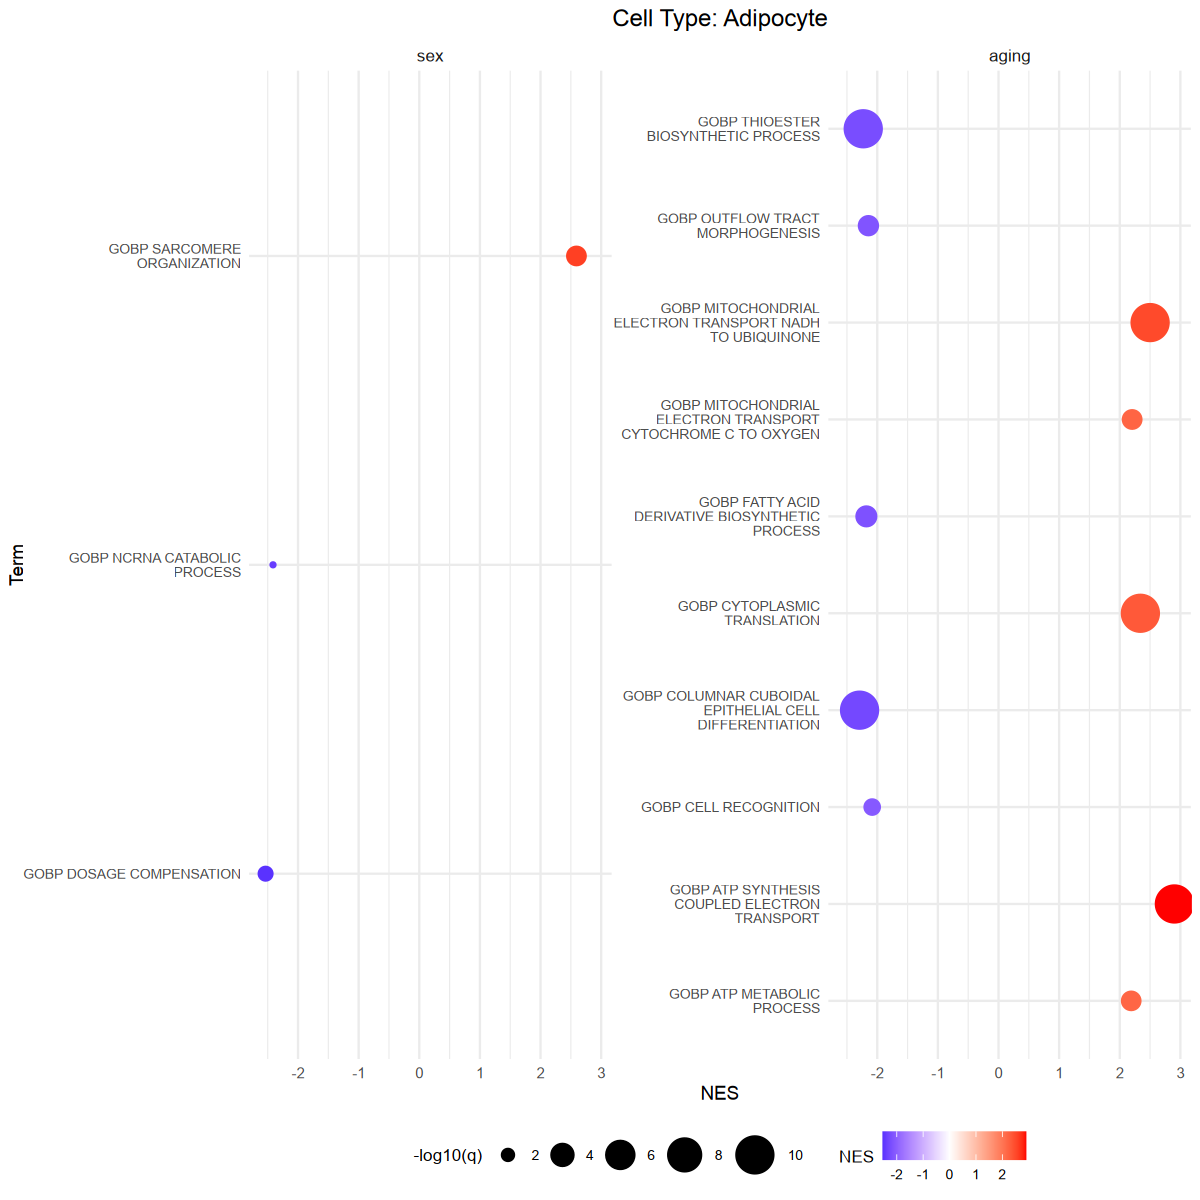

Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”


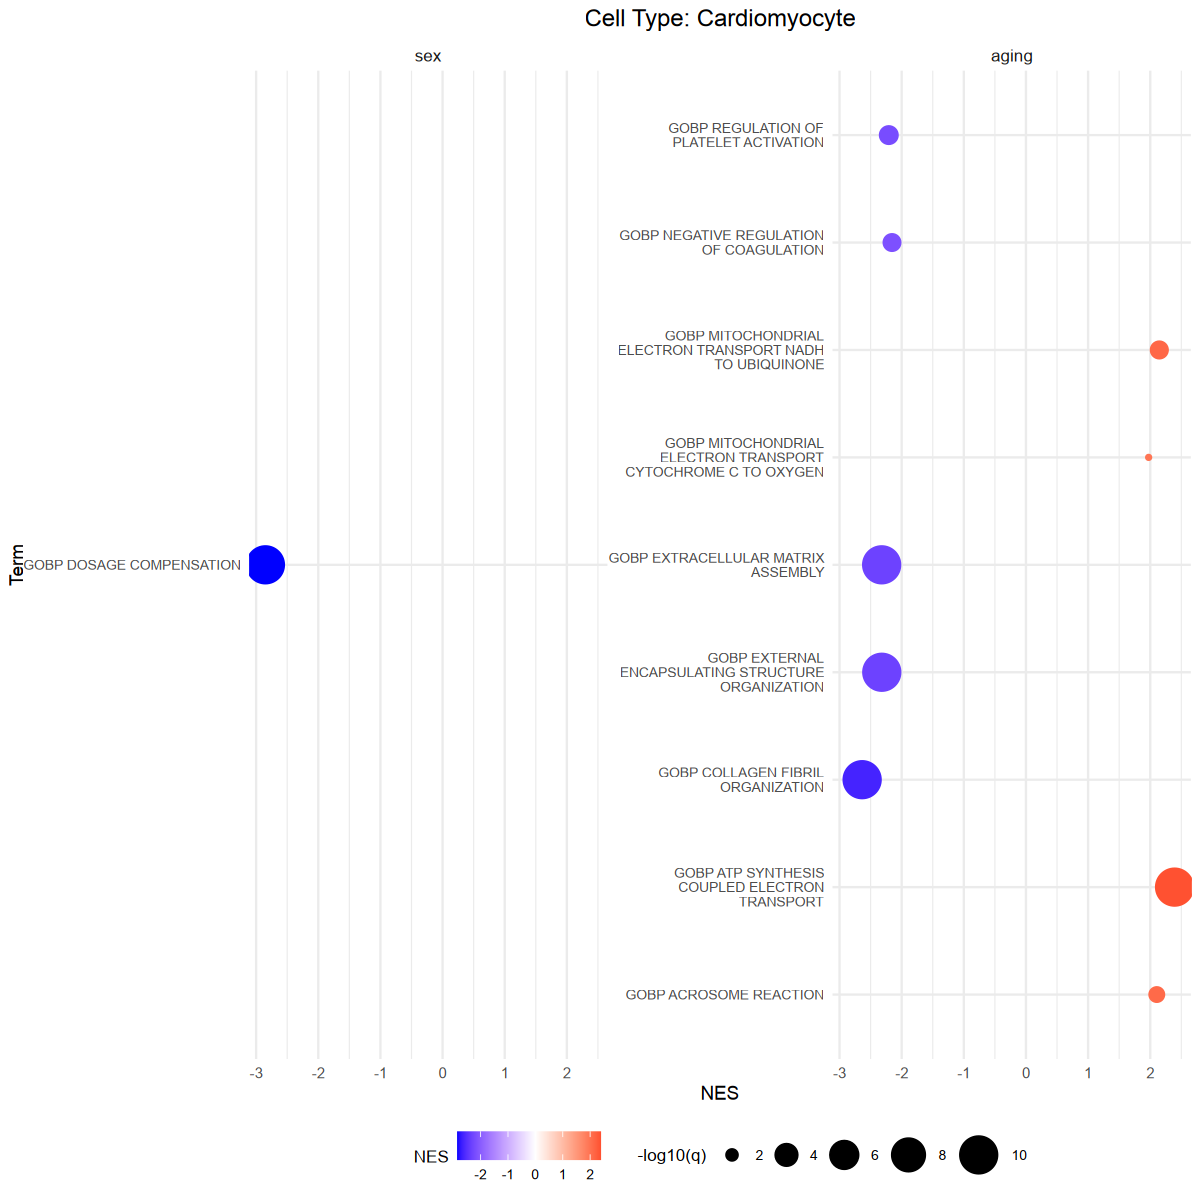

Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”


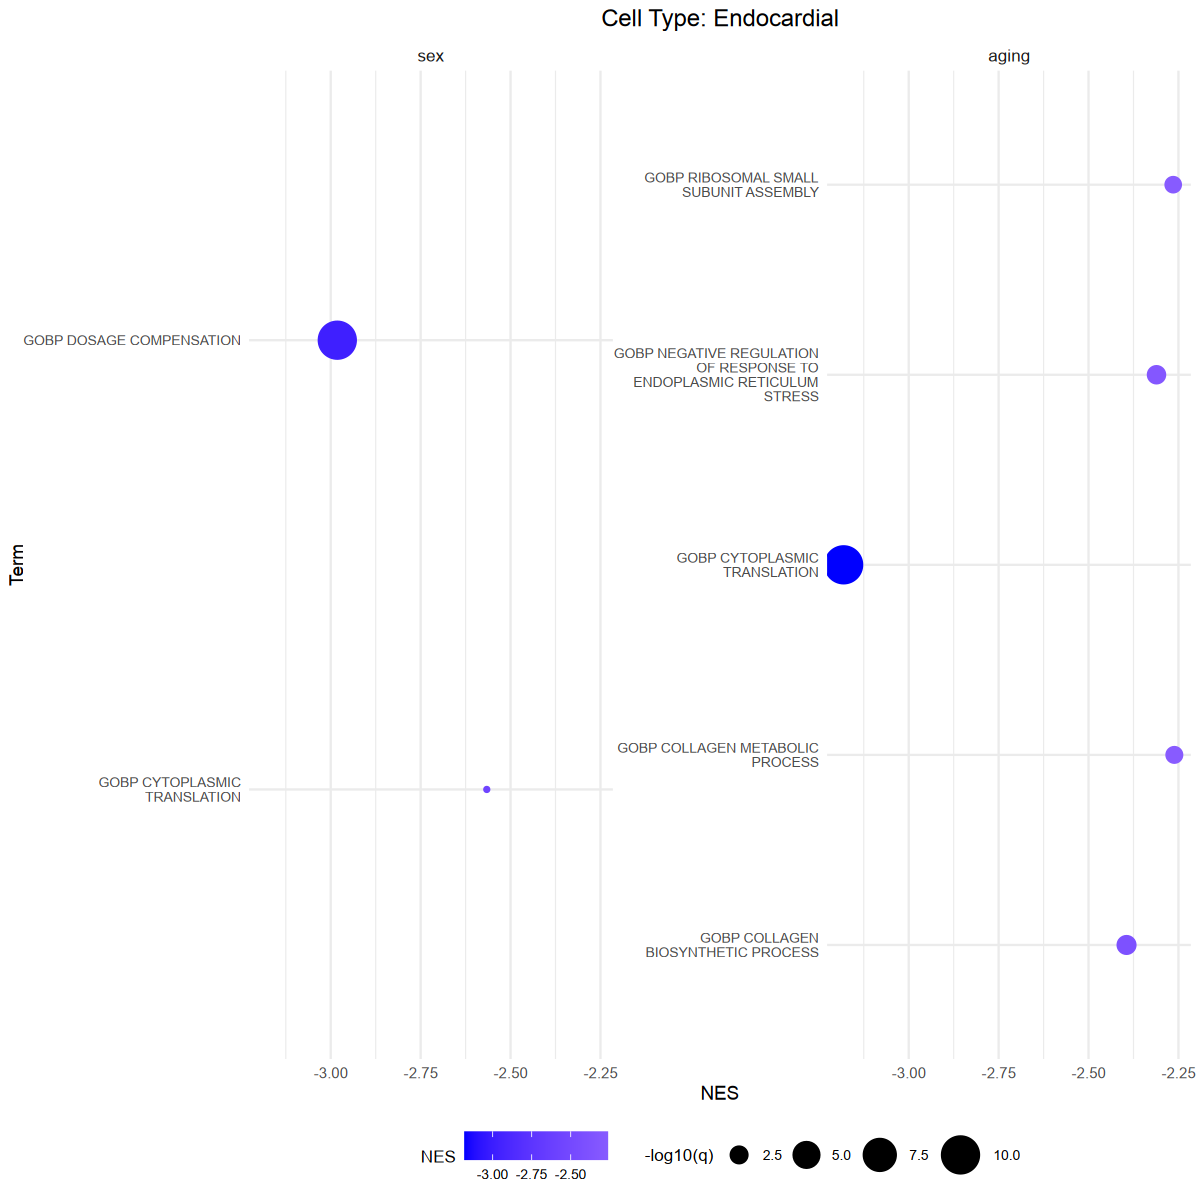

Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”


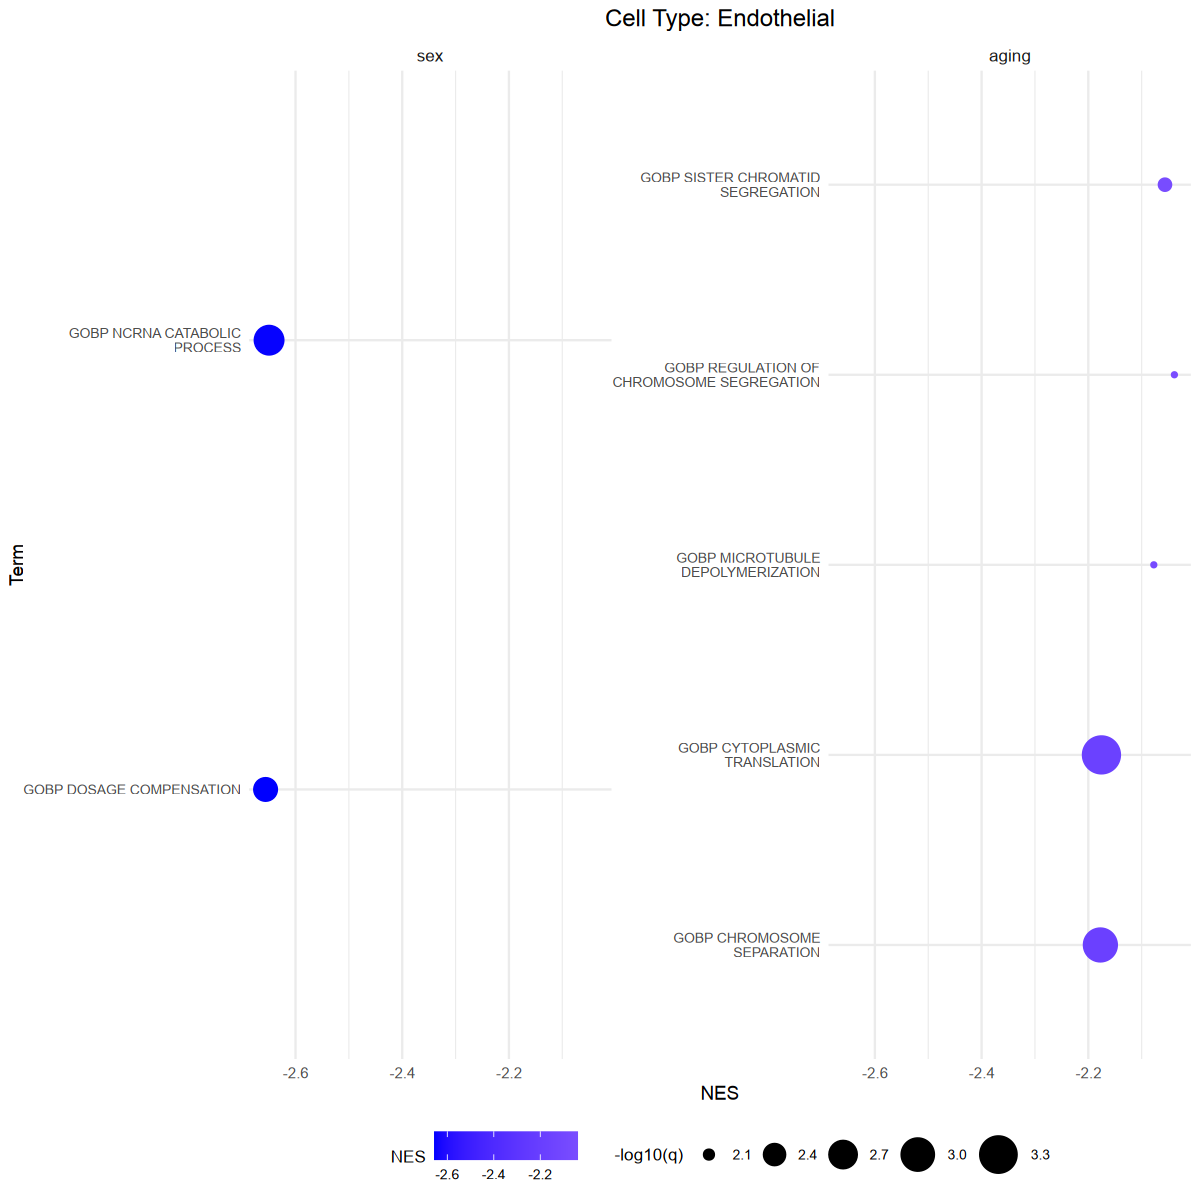

Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”


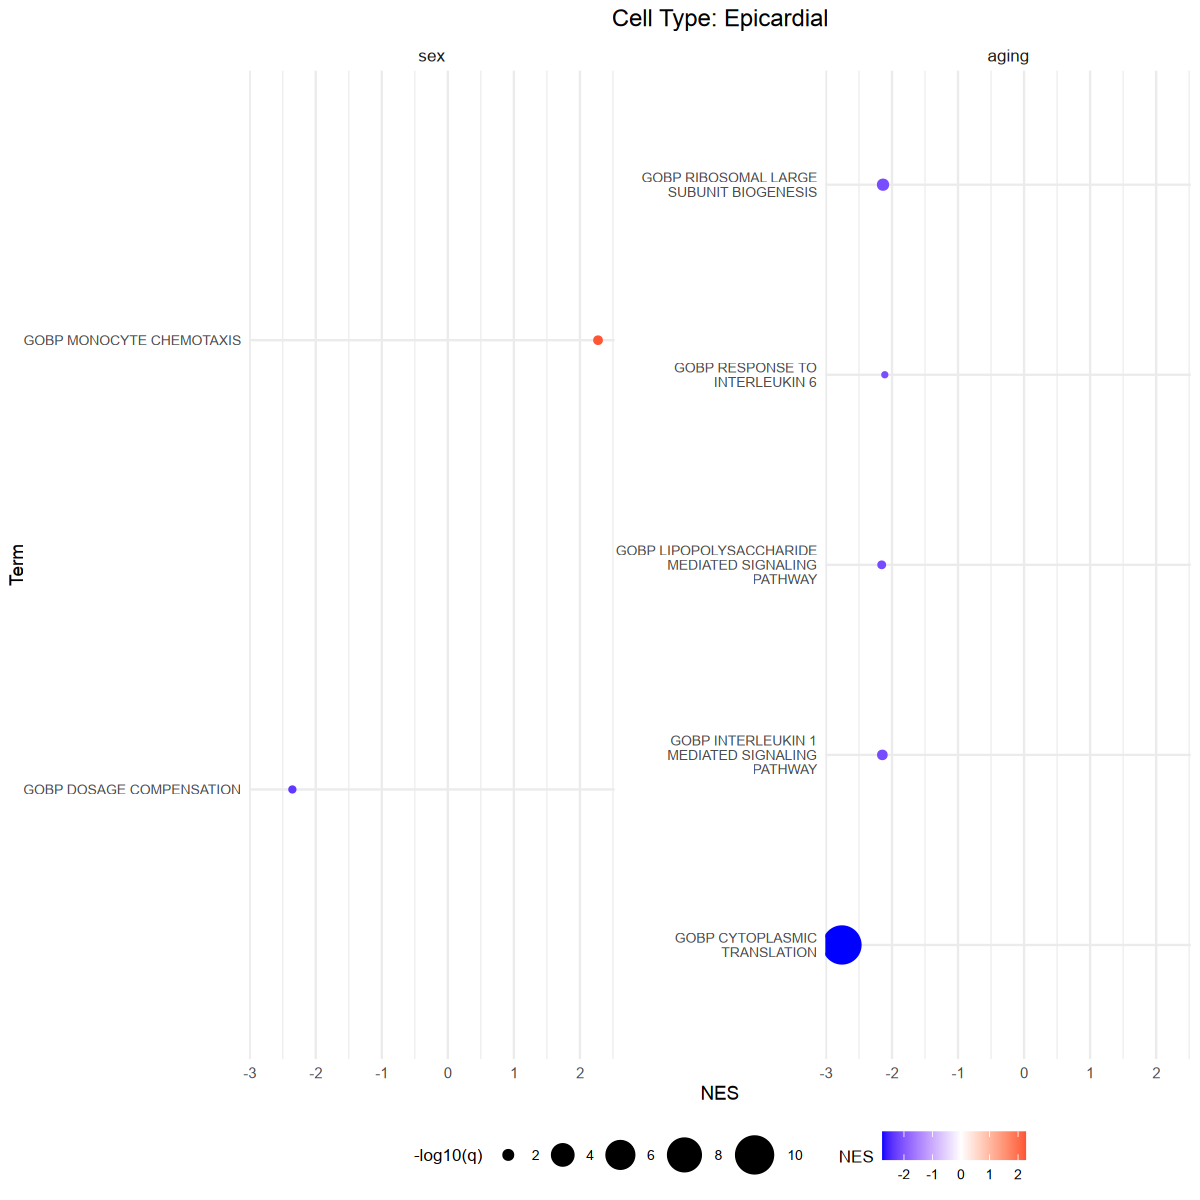

Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”


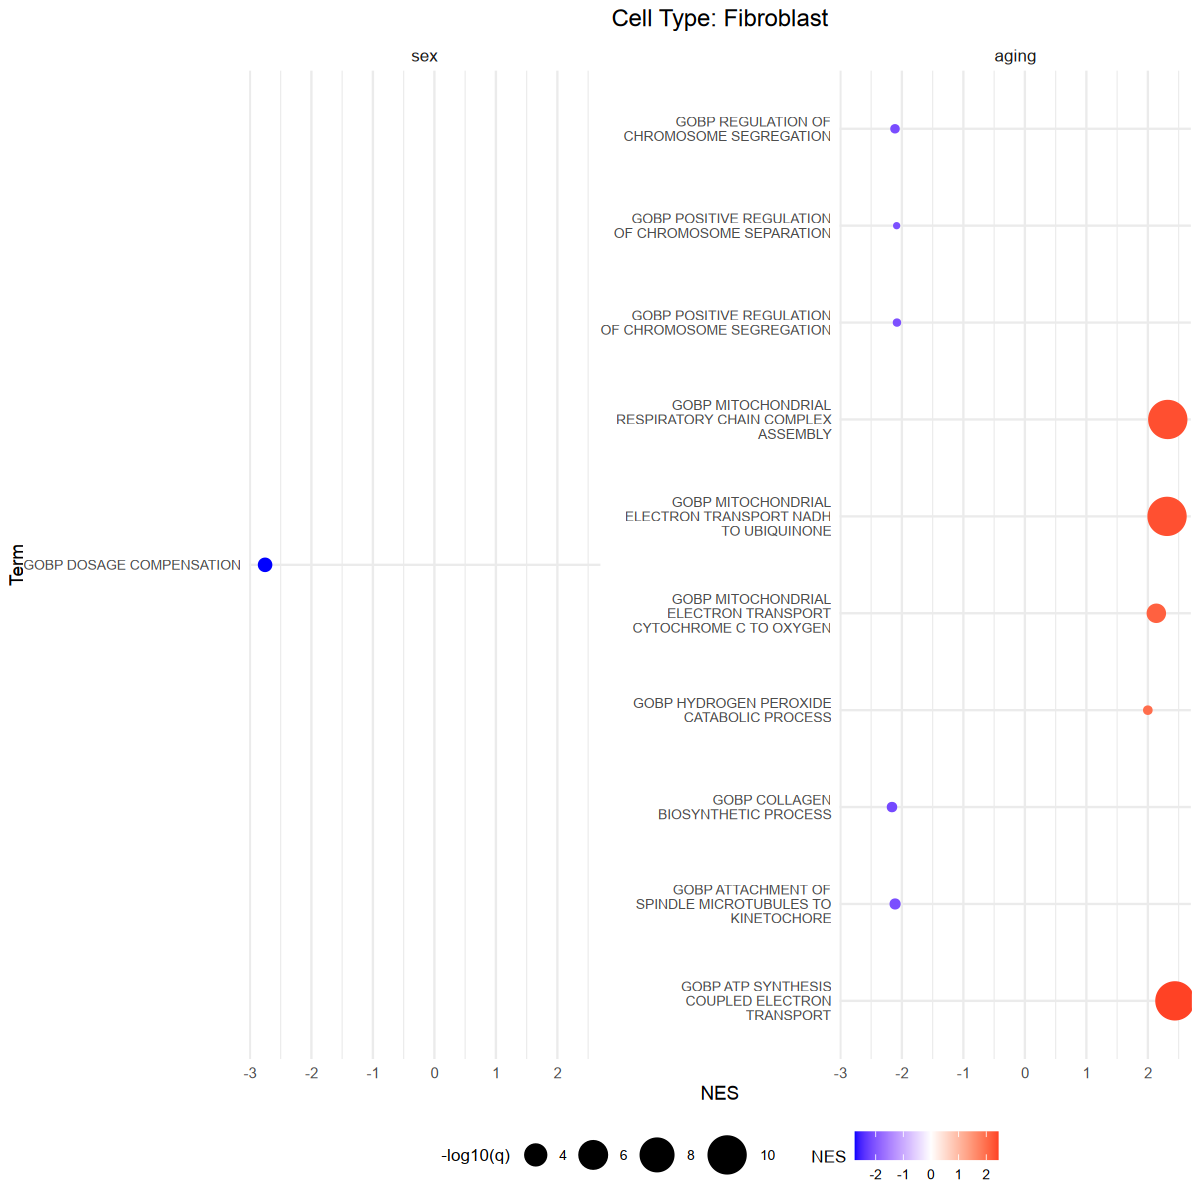

Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”


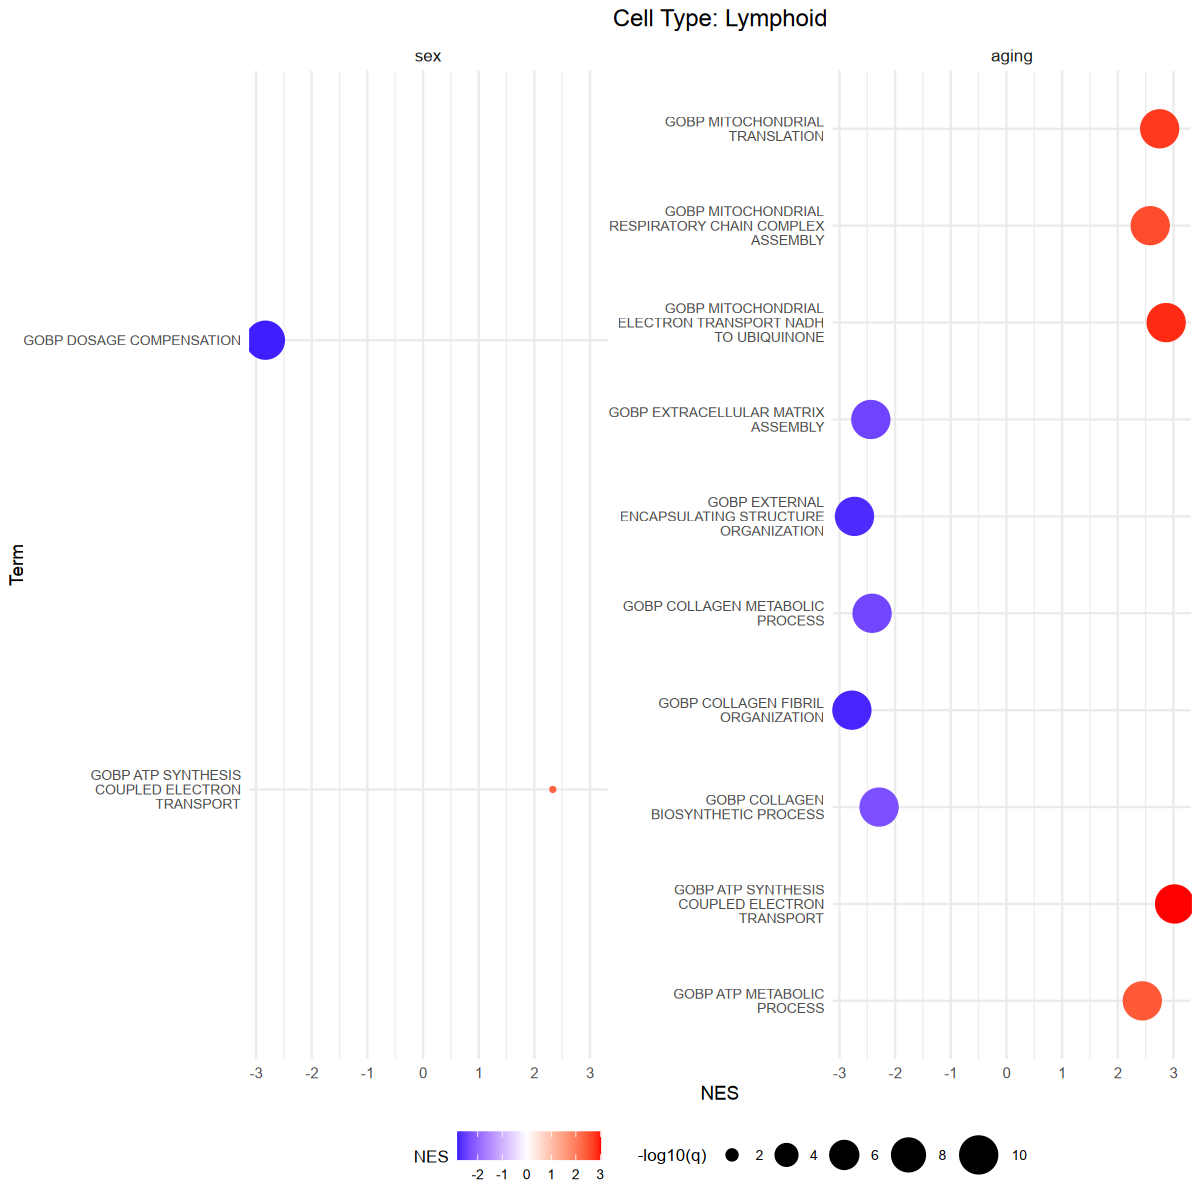

Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”


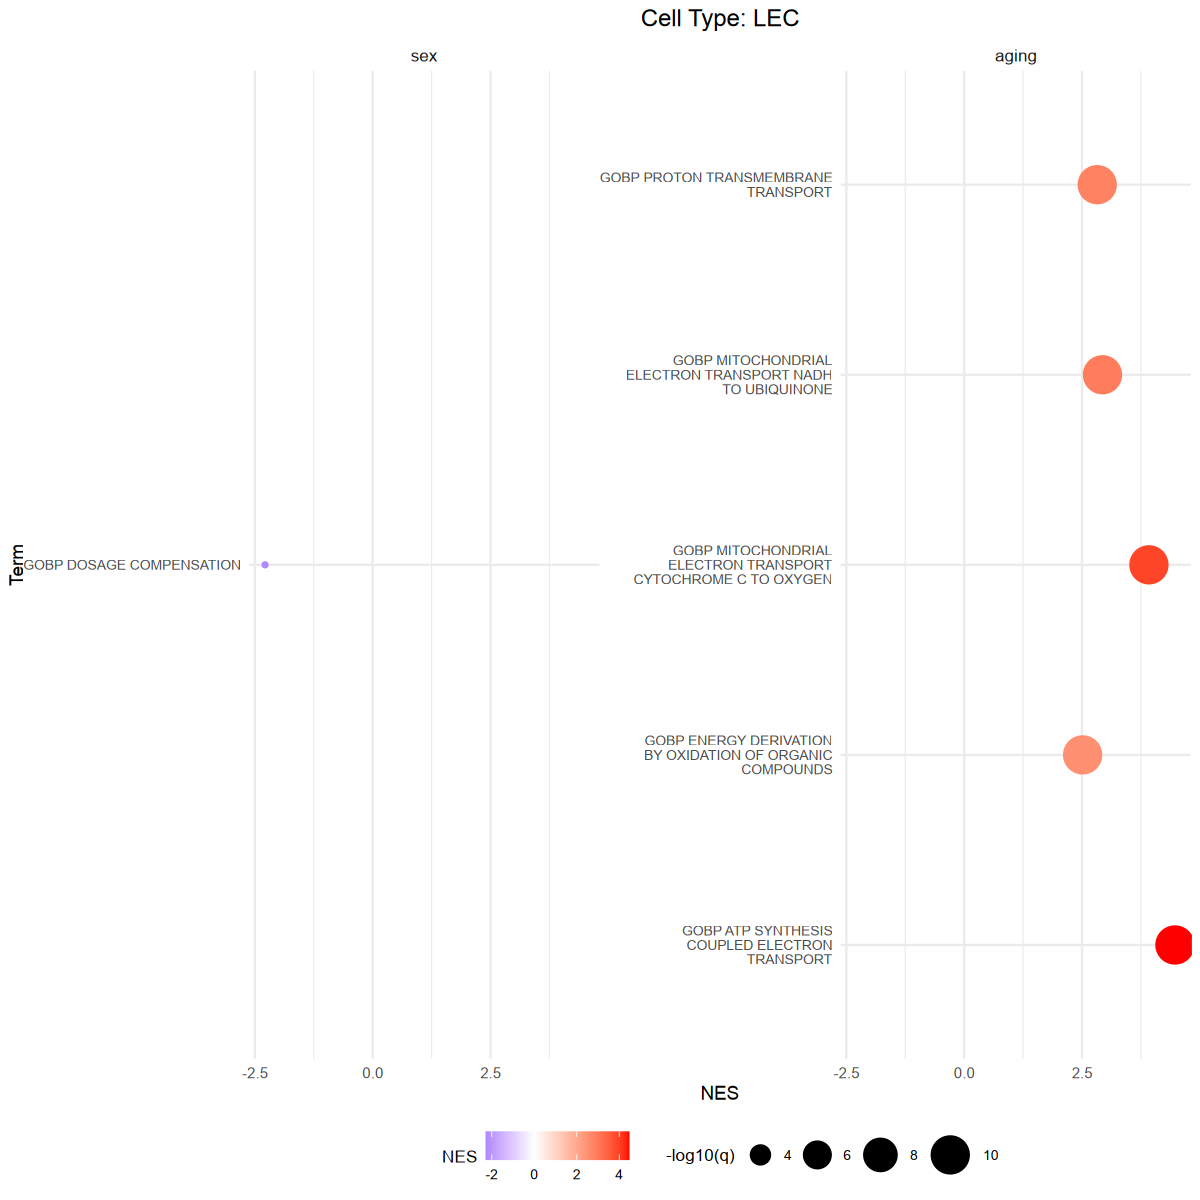

Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”


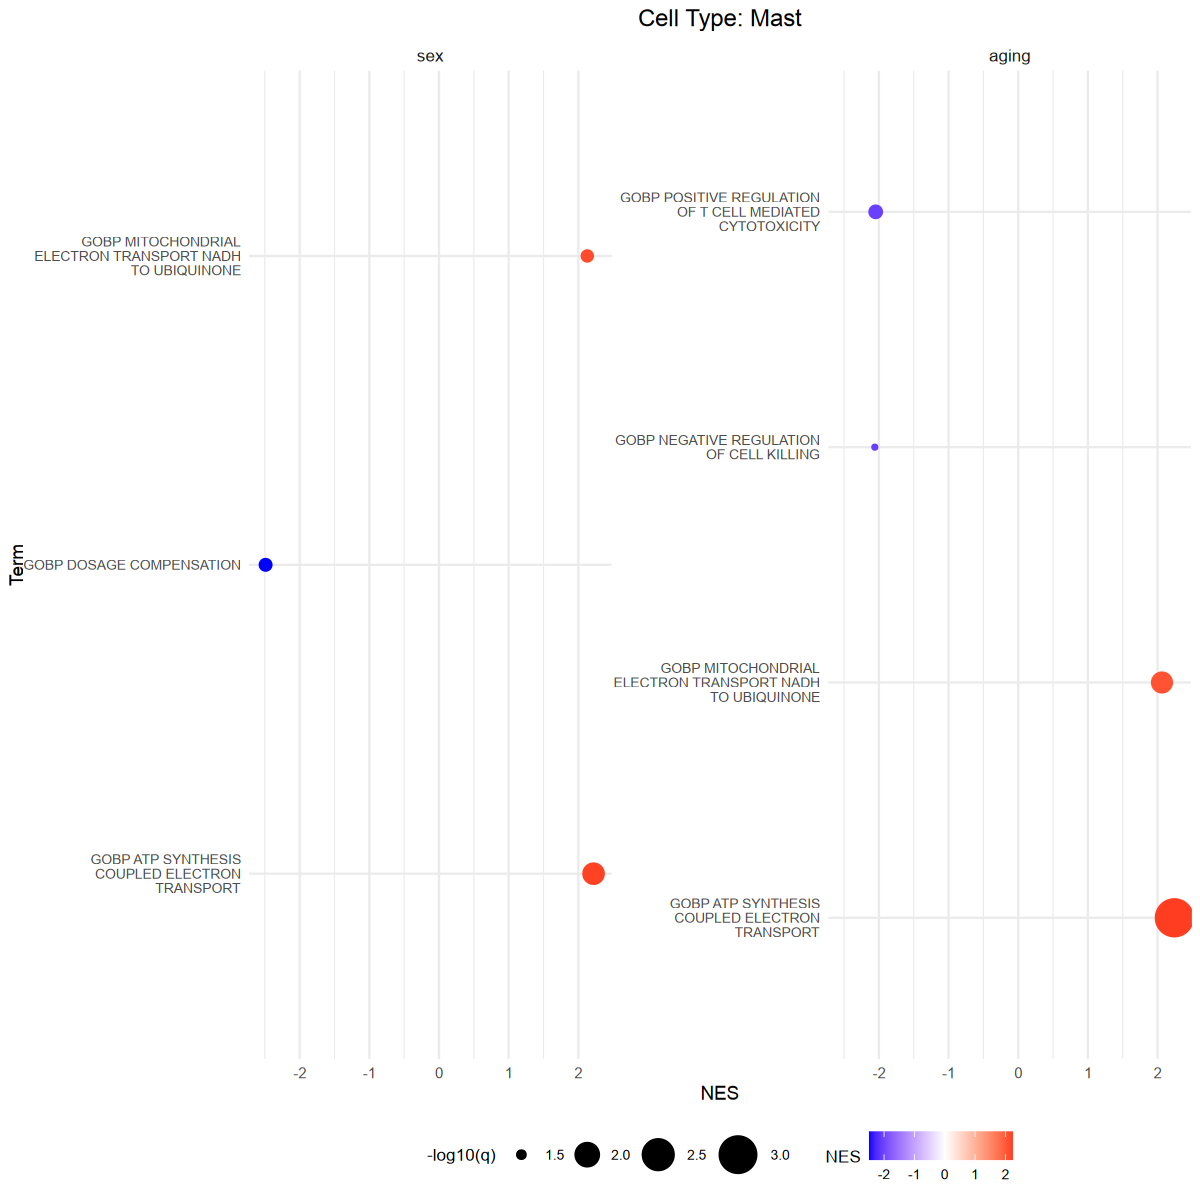

Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”


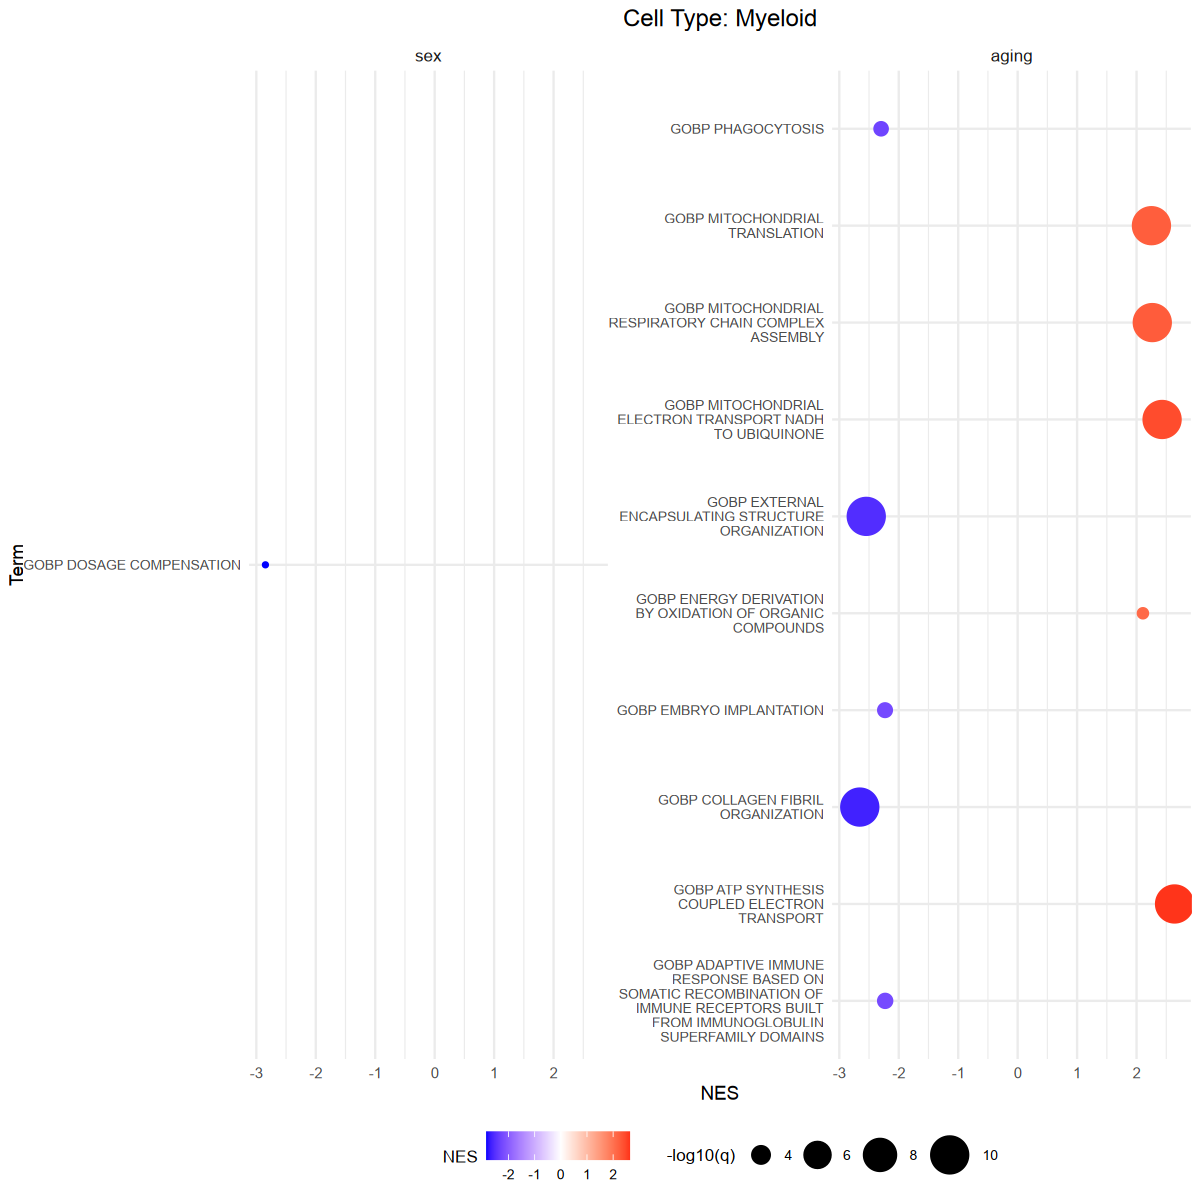

Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”


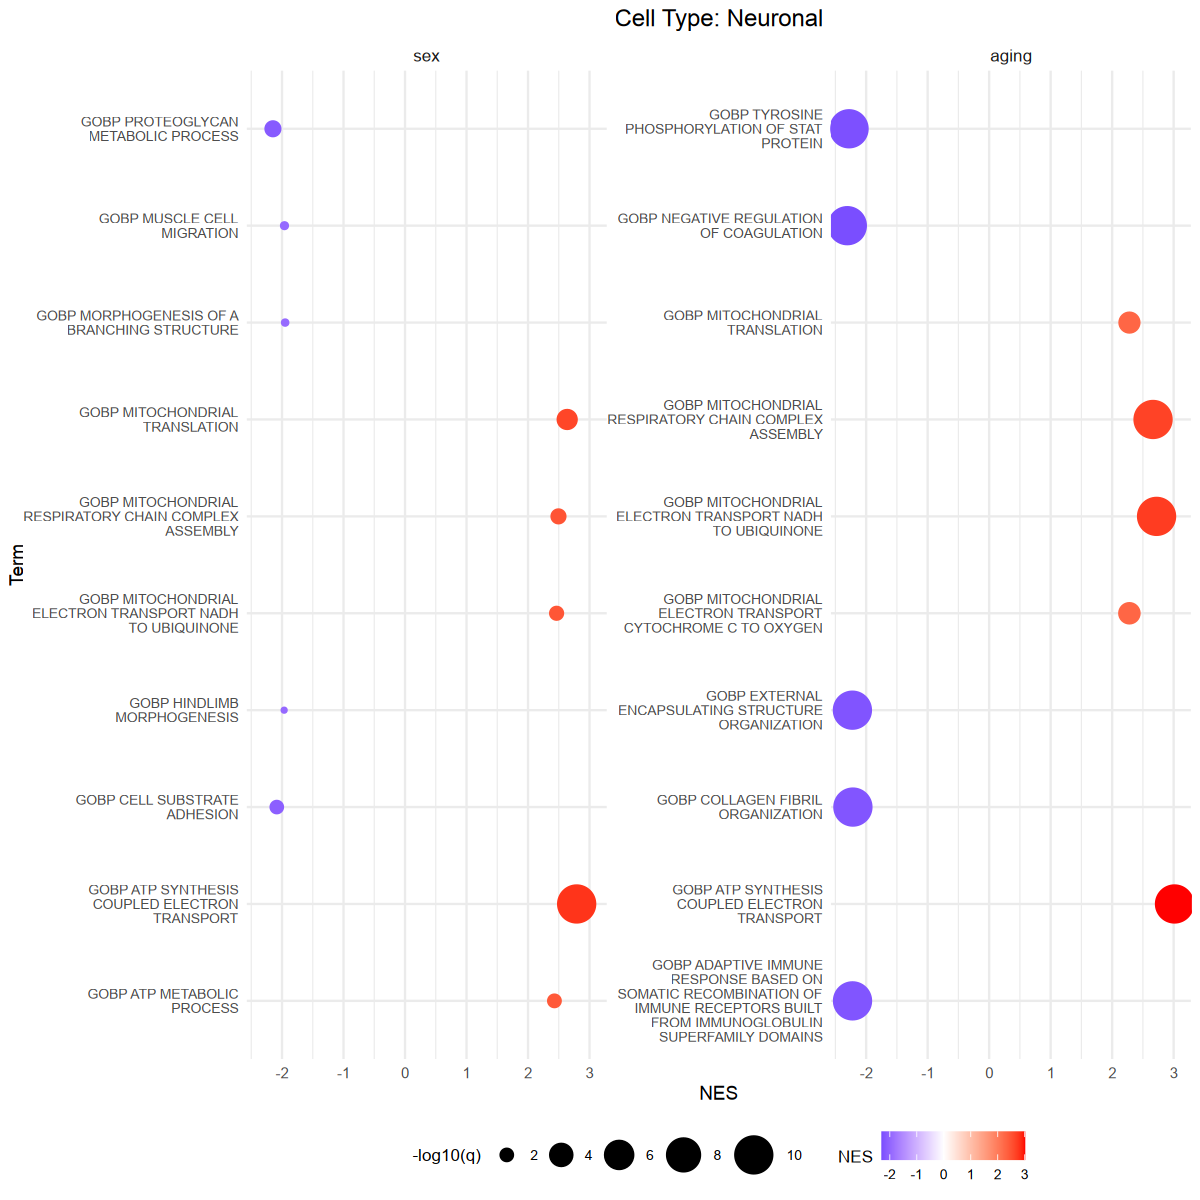

Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”


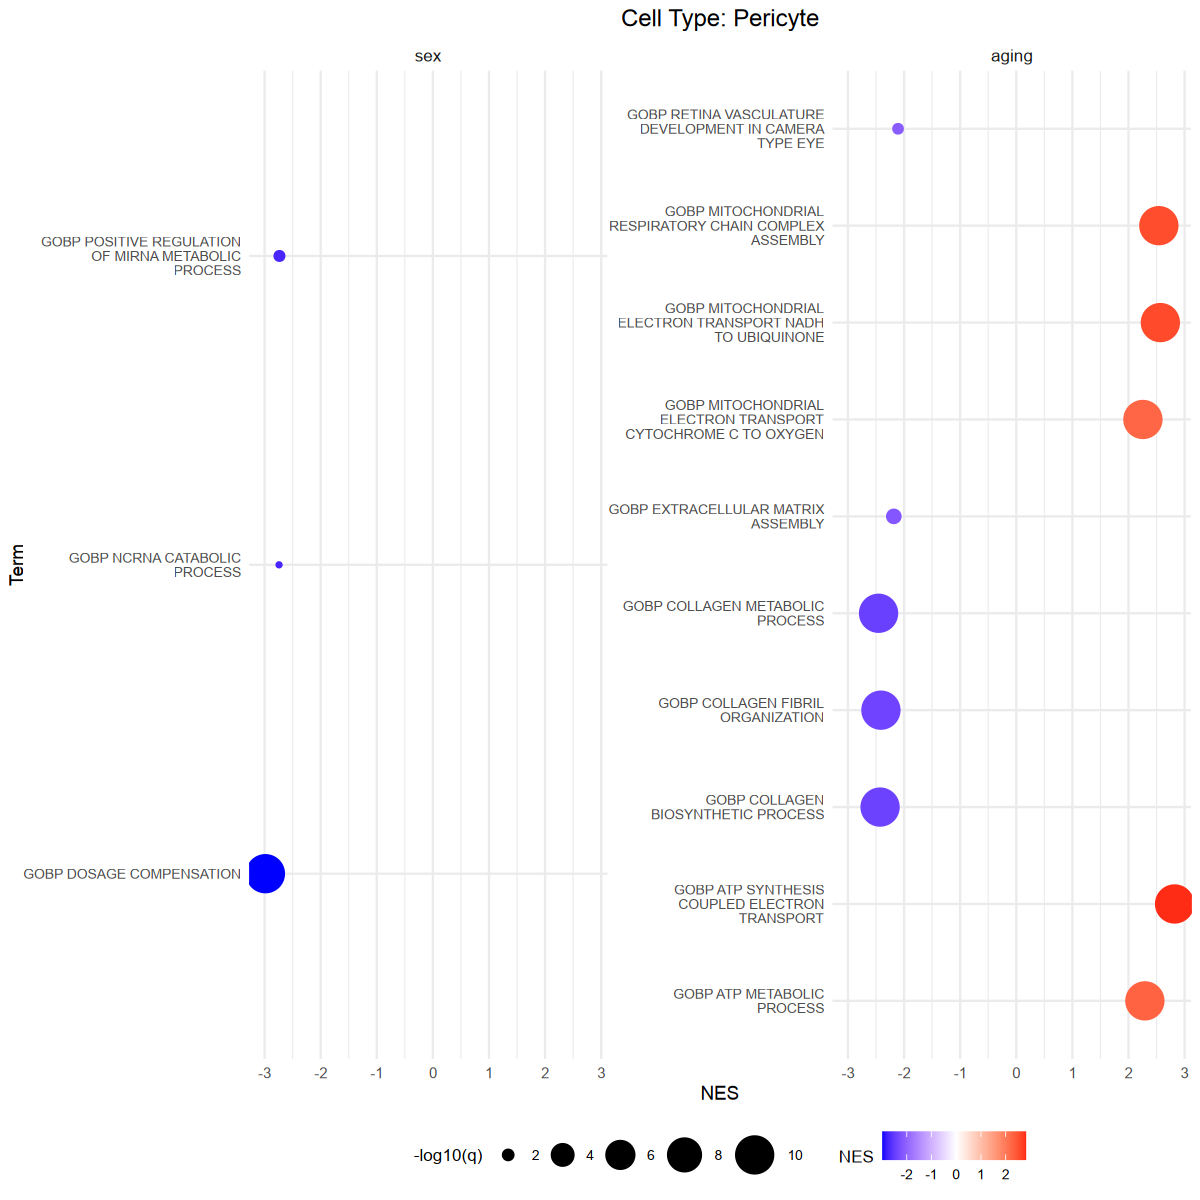

Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `hjust` theme element is not defined in the element hierarchy.”


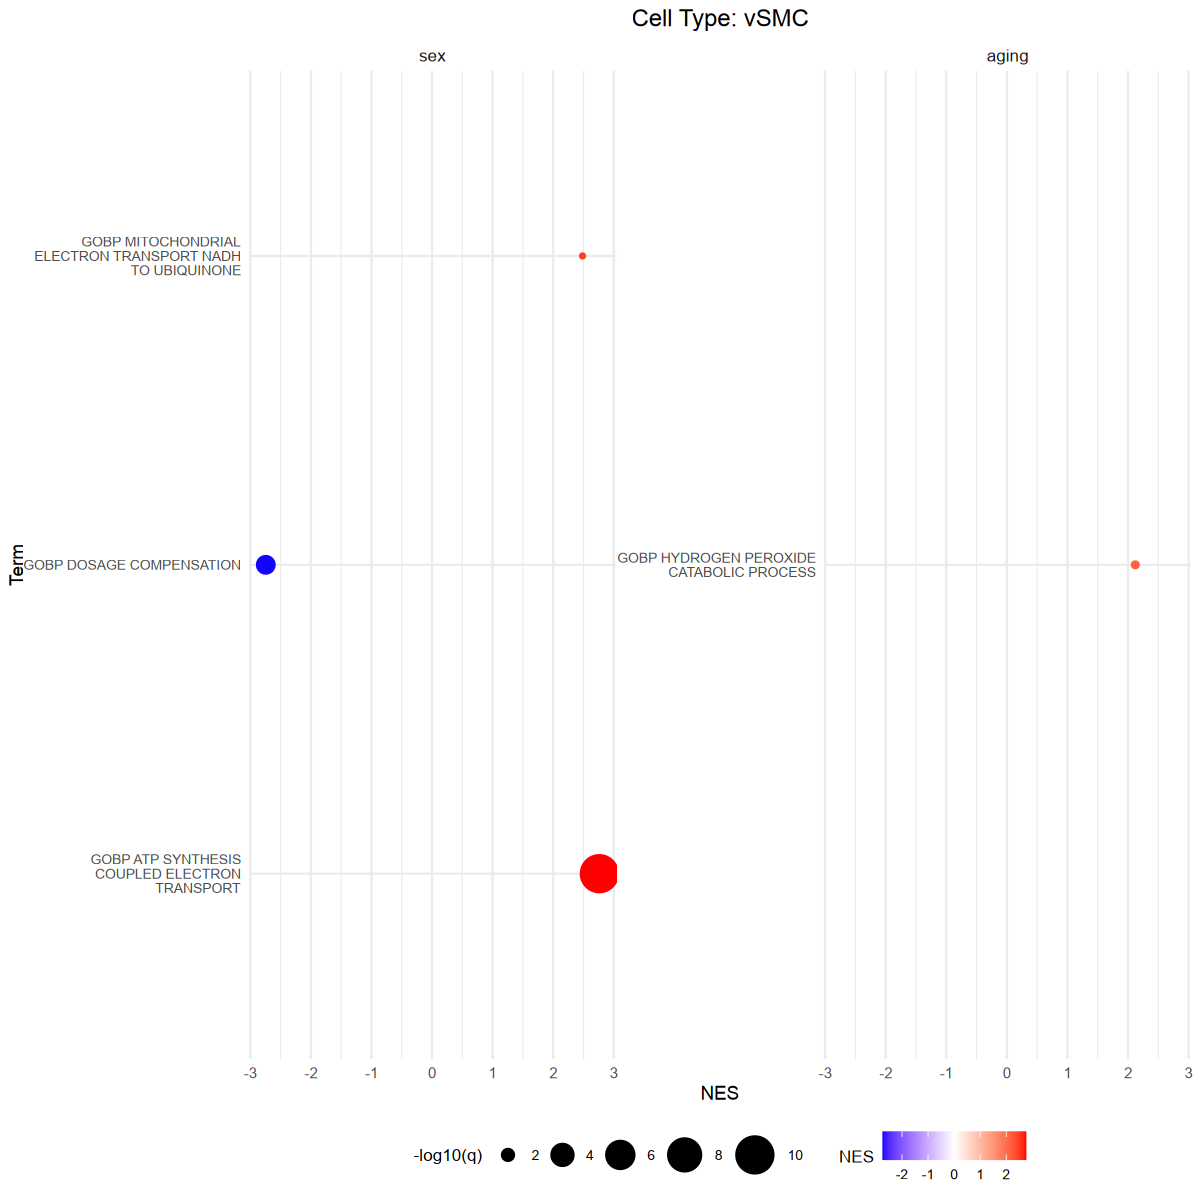

In [20]:
options(repr.plot.width = 10, repr.plot.height = 10)

# loop through each cell type and generate/save the plot
for (cell_type in cell_types) {
  
  # generate the plot
  fig <- produce_cell_type_plot(all_results_df = all_gsea_df, cell_type_val = cell_type)
  print(fig)
    
  # save the plot as a PDF file
  ggsave(paste0(output_dir, cell_type, "_gsea_facet_plot.pdf"), 
         plot = fig, width = 10, height = 10)
}

### Produce a plot that includes all of the cell types

For simplicity of the figure, filter to those terms that have more than 5 instances overall as significant

In [21]:
stricter_q_val <- 0.05
further_filtered_df <- all_gsea_df %>% dplyr::filter(`FDR q-val` < stricter_q_val)	

In [22]:
counts_per_term <- sort(table(further_filtered_df$Term))

In [30]:
most_common_terms <- names(counts_per_term[counts_per_term > 3])

In [31]:
further_filtered_df <- further_filtered_df %>% filter(Term %in% most_common_terms)

In [32]:
unique(further_filtered_df$Term)
length(unique(further_filtered_df$Term))

[1] GOBP DOSAGE COMPENSATION                                      
[2] GOBP ATP SYNTHESIS\nCOUPLED ELECTRON\nTRANSPORT               
[3] GOBP MITOCHONDRIAL\nELECTRON TRANSPORT NADH\nTO UBIQUINONE    
[4] GOBP MITOCHONDRIAL\nELECTRON TRANSPORT\nCYTOCHROME C TO OXYGEN
[5] GOBP MITOCHONDRIAL\nRESPIRATORY CHAIN COMPLEX\nASSEMBLY       
23 Levels: GOBP ATP SYNTHESIS\nCOUPLED ELECTRON\nTRANSPORT ...

[1] 5

In [33]:
# order these thematically:
further_filtered_df$Term <- factor(further_filtered_df$Term, c("GOBP ATP SYNTHESIS\nCOUPLED ELECTRON\nTRANSPORT", 
                                                               "GOBP ATP METABOLIC\nPROCESS", 
                                                               "GOBP ENERGY DERIVATION\nBY OXIDATION OF ORGANIC\nCOMPOUNDS", 
                                                              "GOBP MITOCHONDRIAL\nELECTRON TRANSPORT NADH\nTO UBIQUINONE", 
                                                              "GOBP MITOCHONDRIAL\nRESPIRATORY CHAIN COMPLEX\nASSEMBLY",
                                                              "GOBP MITOCHONDRIAL\nELECTRON TRANSPORT\nCYTOCHROME C TO OXYGEN", 
                                                              "GOBP MITOCHONDRIAL\nTRANSLATION", 
                                                              "GOBP CYTOPLASMIC\nTRANSLATION", 
                                                               "GOBP RIBOSOMAL LARGE\nSUBUNIT BIOGENESIS",
                                                               "GOBP RIBONUCLEOPROTEIN\nCOMPLEX BIOGENESIS",
                                                              "GOBP RIBOSOME ASSEMBLY", 
                                                              "GOBP NCRNA CATABOLIC\nPROCESS",
                                                              "GOBP COLLAGEN FIBRIL\nORGANIZATION",
                                                              "GOBP NEUROPEPTIDE\nSIGNALING PATHWAY",
                                                              "GOBP CELL KILLING",
                                                              "GOBP HUMORAL IMMUNE\nRESPONSE",
                                                              "GOBP ANTIGEN PROCESSING\nAND PRESENTATION OF\nPEPTIDE ANTIGEN",
                                                              "GOBP REGULATION OF\nCHROMOSOME SEGREGATION", 
                                                              "GOBP SISTER CHROMATID\nSEGREGATION",
                                                              "GOBP NUCLEAR CHROMOSOME\nSEGREGATION",
                                                              "GOBP CHROMOSOME\nSEPARATION", 
                                                              "GOBP SARCOMERE\nORGANIZATION",
                                                              "GOBP DOSAGE COMPENSATION")
                                  )

In [34]:
further_filtered_df$Term

[1] GOBP DOSAGE COMPENSATION                                      
 [2] GOBP ATP SYNTHESIS\nCOUPLED ELECTRON\nTRANSPORT               
 [3] GOBP MITOCHONDRIAL\nELECTRON TRANSPORT NADH\nTO UBIQUINONE    
 [4] GOBP MITOCHONDRIAL\nELECTRON TRANSPORT\nCYTOCHROME C TO OXYGEN
 [5] GOBP DOSAGE COMPENSATION                                      
 [6] GOBP ATP SYNTHESIS\nCOUPLED ELECTRON\nTRANSPORT               
 [7] GOBP MITOCHONDRIAL\nELECTRON TRANSPORT NADH\nTO UBIQUINONE    
 [8] GOBP MITOCHONDRIAL\nELECTRON TRANSPORT\nCYTOCHROME C TO OXYGEN
 [9] GOBP DOSAGE COMPENSATION                                      
[10] GOBP DOSAGE COMPENSATION                                      
[11] GOBP DOSAGE COMPENSATION                                      
[12] GOBP DOSAGE COMPENSATION                                      
[13] GOBP ATP SYNTHESIS\nCOUPLED ELECTRON\nTRANSPORT               
[14] GOBP MITOCHONDRIAL\nRESPIRATORY CHAIN COMPLEX\nASSEMBLY       
[15] GOBP MITOCHONDRIAL\nELECTRON TRANSPORT NADH\nTO UBIQUINONE    
[16] GOBP MITOCHONDRIAL\nELECTRON TRANSPORT\nCYTOCHROME C TO OXYGEN
[17] GOBP ATP SYNTHESIS\nCOUPLED ELECTRON\nTRANSPORT               
[18] GOBP DOSAGE COMPENSATION                                      
[19] GOBP ATP SYNTHESIS\nCOUPLED ELECTRON\nTRANSPORT               
[20] GOBP MITOCHONDRIAL\nELECTRON TRANSPORT NADH\nTO UBIQUINONE    
[21] GOBP MITOCHONDRIAL\nRESPIRATORY CHAIN COMPLEX\nASSEMBLY       
[22] GOBP DOSAGE COMPENSATION                                      
[23] GOBP ATP SYNTHESIS\nCOUPLED ELECTRON\nTRANSPORT               
[24] GOBP MITOCHONDRIAL\nELECTRON TRANSPORT\nCYTOCHROME C TO OXYGEN
[25] GOBP MITOCHONDRIAL\nELECTRON TRANSPORT NADH\nTO UBIQUINONE    
[26] GOBP ATP SYNTHESIS\nCOUPLED ELECTRON\nTRANSPORT               
[27] GOBP MITOCHONDRIAL\nELECTRON TRANSPORT NADH\nTO UBIQUINONE    
[28] GOBP DOSAGE COMPENSATION                                      
[29] GOBP ATP SYNTHESIS\nCOUPLED ELECTRON\nTRANSPORT               
[30] GOBP MITOCHONDRIAL\nELECTRON TRANSPORT NADH\nTO UBIQUINONE    
[31] GOBP DOSAGE COMPENSATION                                      
[32] GOBP ATP SYNTHESIS\nCOUPLED ELECTRON\nTRANSPORT               
[33] GOBP MITOCHONDRIAL\nELECTRON TRANSPORT NADH\nTO UBIQUINONE    
[34] GOBP MITOCHONDRIAL\nRESPIRATORY CHAIN COMPLEX\nASSEMBLY       
[35] GOBP ATP SYNTHESIS\nCOUPLED ELECTRON\nTRANSPORT               
[36] GOBP MITOCHONDRIAL\nRESPIRATORY CHAIN COMPLEX\nASSEMBLY       
[37] GOBP MITOCHONDRIAL\nELECTRON TRANSPORT NADH\nTO UBIQUINONE    
[38] GOBP ATP SYNTHESIS\nCOUPLED ELECTRON\nTRANSPORT               
[39] GOBP MITOCHONDRIAL\nELECTRON TRANSPORT NADH\nTO UBIQUINONE    
[40] GOBP MITOCHONDRIAL\nRESPIRATORY CHAIN COMPLEX\nASSEMBLY       
[41] GOBP MITOCHONDRIAL\nELECTRON TRANSPORT\nCYTOCHROME C TO OXYGEN
[42] GOBP DOSAGE COMPENSATION                                      
[43] GOBP ATP SYNTHESIS\nCOUPLED ELECTRON\nTRANSPORT               
[44] GOBP MITOCHONDRIAL\nELECTRON TRANSPORT NADH\nTO UBIQUINONE    
[45] GOBP MITOCHONDRIAL\nRESPIRATORY CHAIN COMPLEX\nASSEMBLY       
[46] GOBP MITOCHONDRIAL\nELECTRON TRANSPORT\nCYTOCHROME C TO OXYGEN
[47] GOBP ATP SYNTHESIS\nCOUPLED ELECTRON\nTRANSPORT               
[48] GOBP MITOCHONDRIAL\nELECTRON TRANSPORT NADH\nTO UBIQUINONE    
[49] GOBP DOSAGE COMPENSATION                                      
23 Levels: GOBP ATP SYNTHESIS\nCOUPLED ELECTRON\nTRANSPORT ...

In [35]:
further_filtered_df$contrast <- factor(further_filtered_df$contrast,  c("sex", "aging", "development", "disease"))

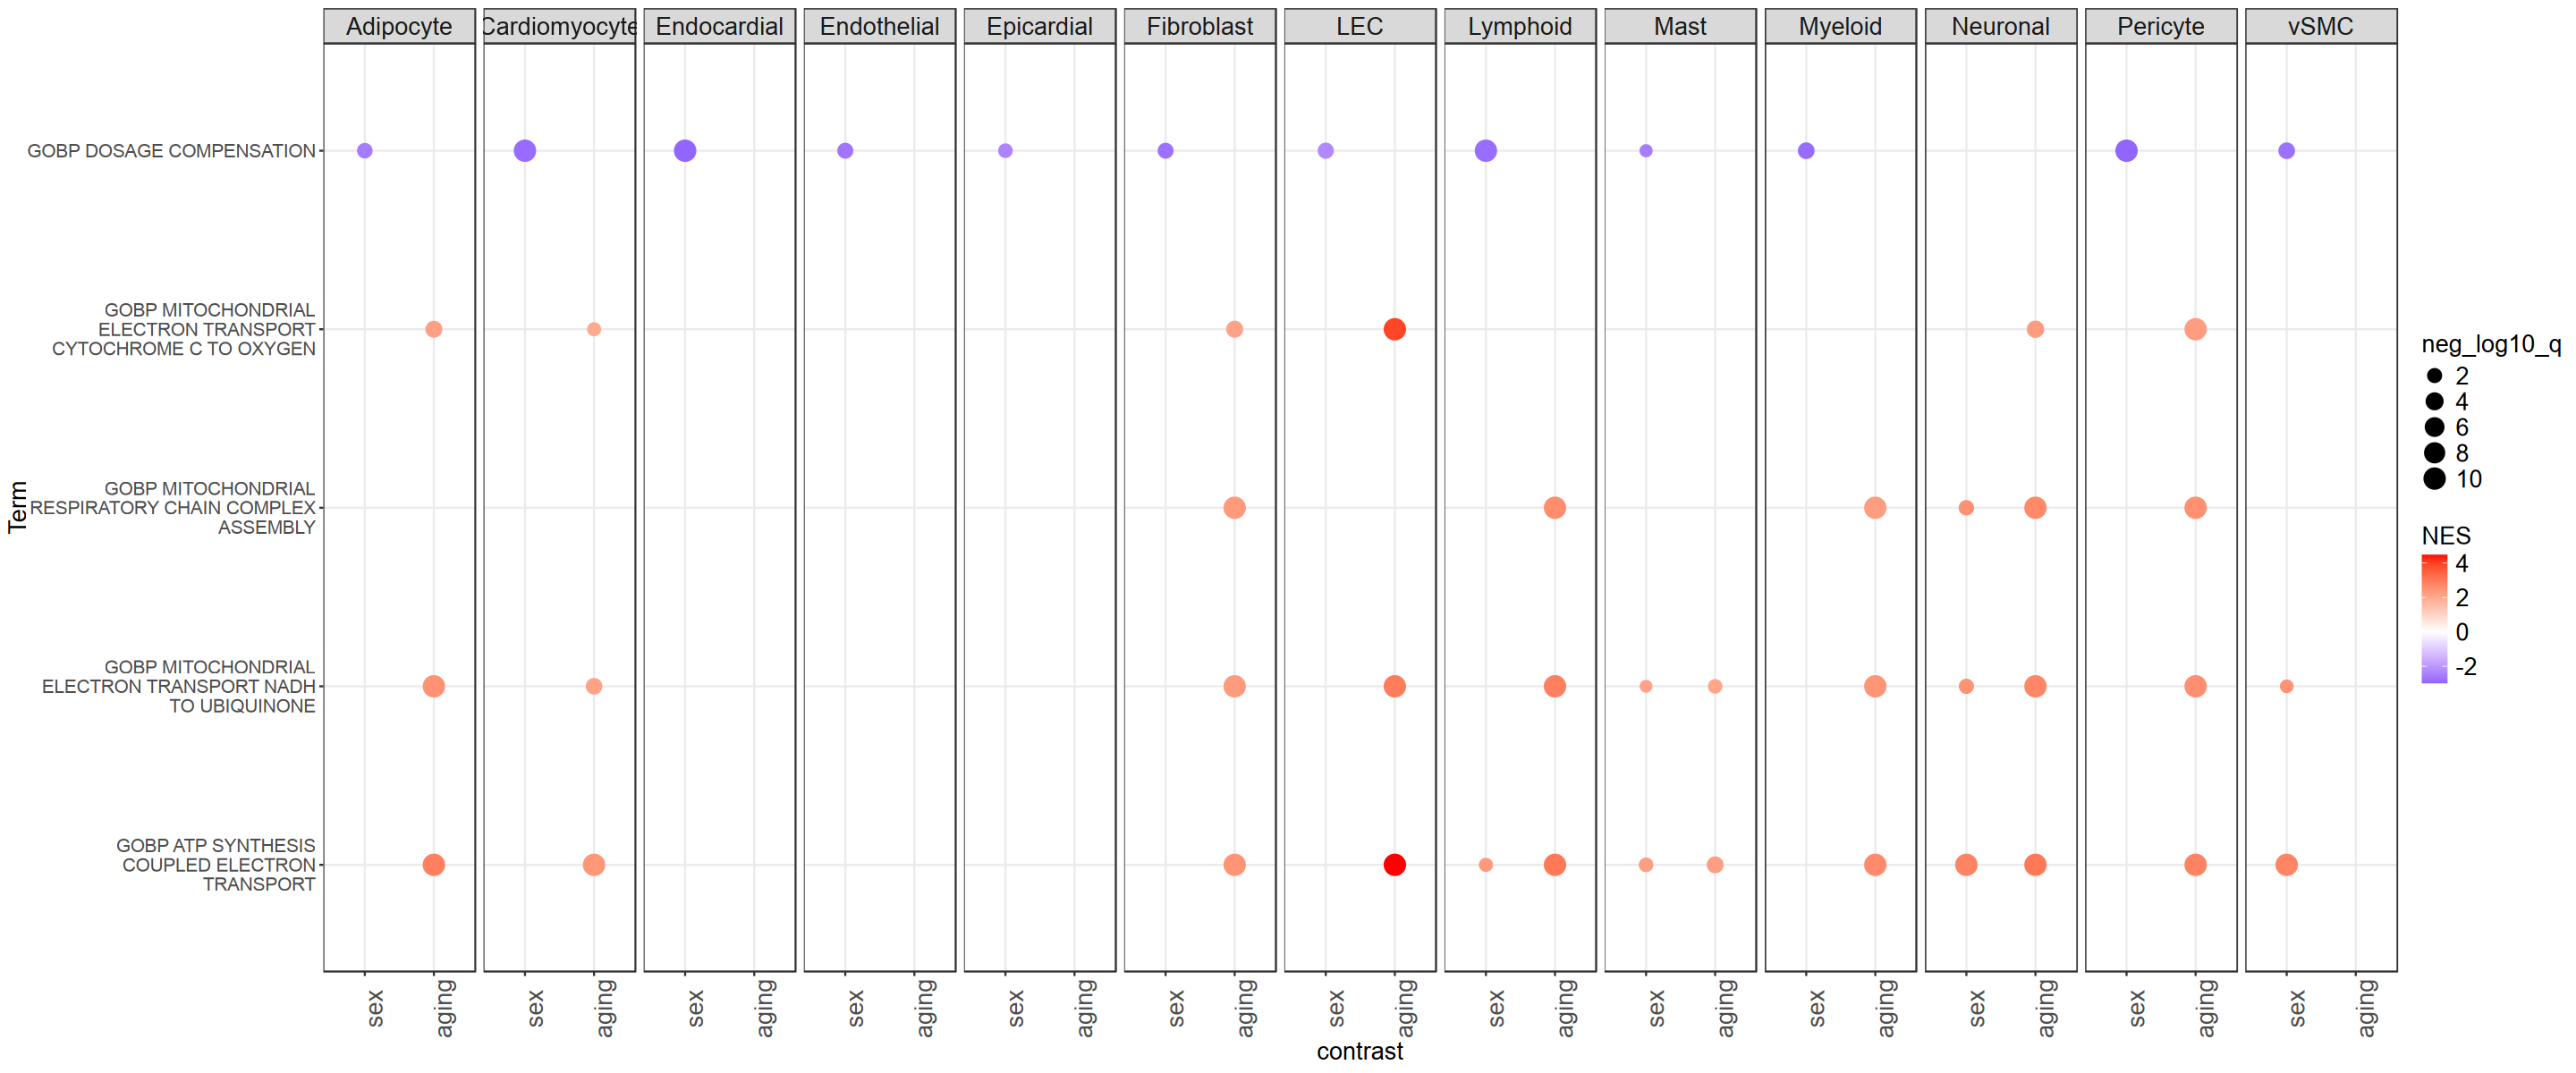

In [37]:
options(repr.plot.width = 24, repr.plot.height = 10)

p3 <- ggplot(data = further_filtered_df, mapping = aes(x = contrast, y = Term, 
                                         size = neg_log10_q,  color = NES)) + 
        scale_size(range = c(3, 6)) +
        geom_point() + 
        facet_wrap(~ cell_type, nrow = 1) + 
        scale_color_gradient2(low = "blue", mid = "white", high = "red", midpoint = 0)  +  
        theme_bw() +
        theme(legend.text = element_text(size = 16), 
         legend.title = element_text(size = 16), 
         plot.title = element_text(size = 24, hjust = 0.5), 
         axis.title.x = element_text(size = 16),
         axis.title.y = element_text(size = 16),
         axis.text.x = element_text(size = 16, angle = 90),
         axis.text.y = element_text(size = 12), 
         strip.text.x = element_text(size = 16))

ggsave(paste0(output_dir, "overall_gsea_facet_plot.pdf"), 
         plot = p3, width = 24, height = 10)

p3